# 📊 Matplotlib — From Basics to Advanced

Matplotlib is Python's foundational plotting library — most other Python visualization tools
(Seaborn, Pandas' `.plot()`, etc.) are built on top of it. It gives you fine-grained control
over every part of a chart.

## Table of Contents
1. [Anatomy of a plot & your first chart](#1)
2. [Common chart types](#2)
3. [Styling: colors, labels, legends, grids](#3)
4. [Subplots — multiple charts in one figure](#4)
5. [Customizing axes & annotations](#5)
6. [Saving figures](#6)
7. [The Object-Oriented API vs pyplot](#7)
8. [Advanced: twin axes, plotting with Pandas](#8)


In [1]:
import matplotlib.pyplot as plt
import numpy as np
print(plt.matplotlib.__version__)

# In a Jupyter notebook, this makes plots render inline automatically:
%matplotlib inline


3.11.0


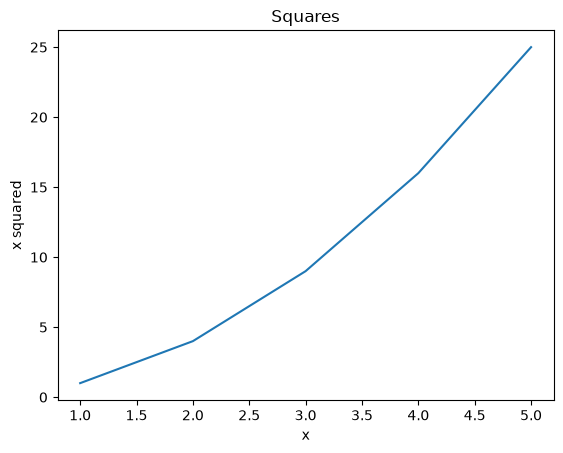

In [2]:
# =========================================================
# YOUR FIRST PLOT
# =========================================================

x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y)              # draws a line plot
plt.title("Squares")         # chart title
plt.xlabel("x")              # x-axis label
plt.ylabel("x squared")      # y-axis label
plt.show()                   # renders the figure (implicit in notebooks, but good practice)

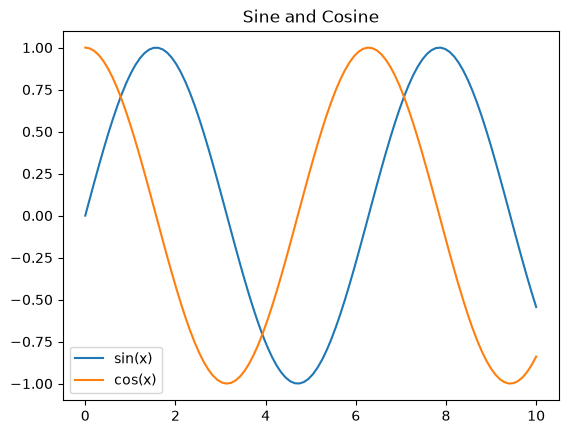

In [3]:
# =========================================================
# LINE PLOT - great for trends over a continuous variable (e.g. time)
# =========================================================

x = np.linspace(0, 10, 100)   # 100 points from 0 to 10

plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)")   # multiple plot() calls layer onto the same chart
plt.legend()                              # shows labels for each line
plt.title("Sine and Cosine")
plt.show()


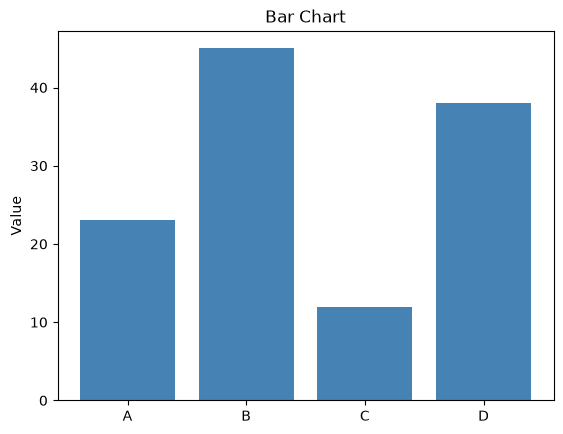

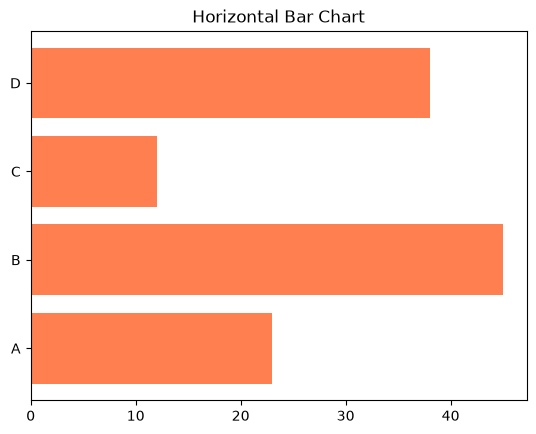

In [4]:
# =========================================================
# BAR CHART - great for comparing categories
# =========================================================

categories = ["A", "B", "C", "D"]
values = [23, 45, 12, 38]

plt.bar(categories, values, color="steelblue")
plt.title("Bar Chart")
plt.ylabel("Value")
plt.show()

# Horizontal bar chart - often better for long category names
plt.barh(categories, values, color="coral")
plt.title("Horizontal Bar Chart")
plt.show()


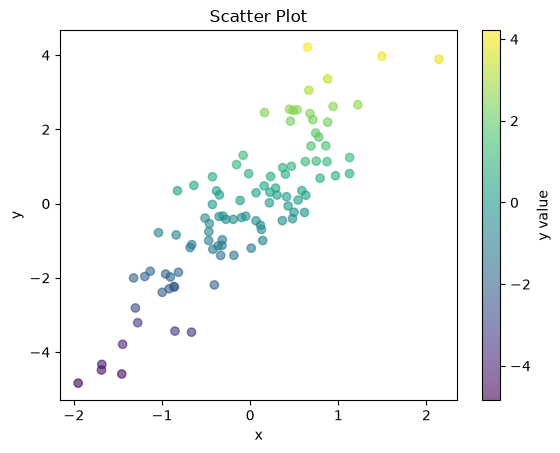

In [5]:
# =========================================================
# SCATTER PLOT - great for showing relationships between two variables
# =========================================================

rng = np.random.default_rng(42)
x = rng.normal(0, 1, 100)
y = x * 2 + rng.normal(0, 1, 100)   # y roughly correlated with x

plt.scatter(x, y, alpha=0.6, c=y, cmap="viridis")   # alpha=transparency, c/cmap=color by value
plt.colorbar(label="y value")                          # shows what the color scale means
plt.title("Scatter Plot")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


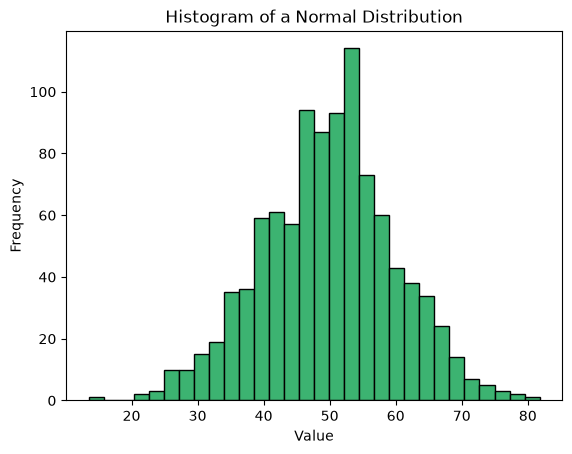

In [6]:
# =========================================================
# HISTOGRAM - great for showing the DISTRIBUTION of a single variable
# =========================================================

data = rng.normal(loc=50, scale=10, size=1000)

plt.hist(data, bins=30, color="mediumseagreen", edgecolor="black")
plt.title("Histogram of a Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


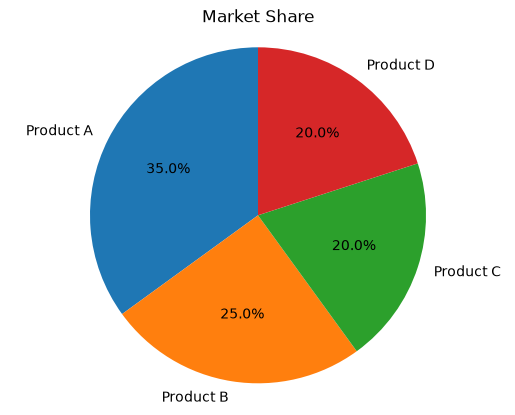

In [7]:
# =========================================================
# PIE CHART - great for showing proportions of a whole (use sparingly - often bar > pie)
# =========================================================

sizes = [35, 25, 20, 20]
labels = ["Product A", "Product B", "Product C", "Product D"]

plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)   # autopct shows percentages
plt.title("Market Share")
plt.axis("equal")   # keeps the pie circular, not elliptical
plt.show()

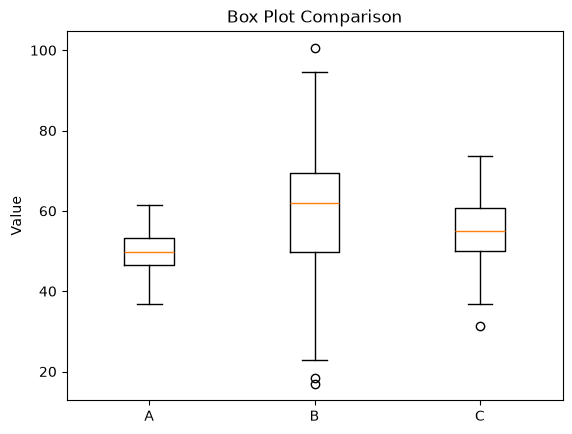

In [8]:
# =========================================================
# BOX PLOT - great for comparing distributions & spotting outliers across groups
# =========================================================

group_a = rng.normal(50, 5, 100)
group_b = rng.normal(60, 15, 100)
group_c = rng.normal(55, 8, 100)

plt.boxplot([group_a, group_b, group_c], tick_labels=["A", "B", "C"])   # 'tick_labels' (renamed from 'labels' in newer matplotlib)
plt.title("Box Plot Comparison")
plt.ylabel("Value")
plt.show()

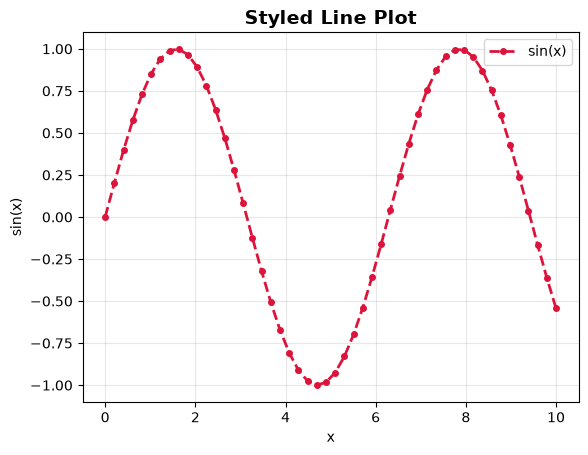

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast']


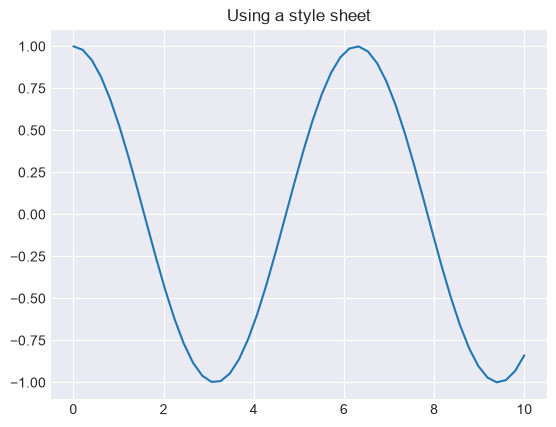

In [9]:
# =========================================================
# STYLING OPTIONS
# =========================================================

x = np.linspace(0, 10, 50)

plt.plot(x, np.sin(x),
         color="crimson",        # line color (name, hex '#RRGGBB', or shorthand like 'r')
         linestyle="--",         # '-' solid, '--' dashed, ':' dotted, '-.' dash-dot
         linewidth=2,
         marker="o",             # marker at each data point: 'o' circle, 's' square, '^' triangle
         markersize=4,
         label="sin(x)")

plt.title("Styled Line Plot", fontsize=14, fontweight="bold")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.legend(loc="upper right")     # loc controls legend position
plt.grid(True, alpha=0.3)         # light gridlines
plt.show()

# Built-in style sheets change the overall look with one line
print(plt.style.available[:5])    # preview a few available styles
with plt.style.context("seaborn-v0_8-darkgrid" if "seaborn-v0_8-darkgrid" in plt.style.available else "ggplot"):
    plt.plot(x, np.cos(x))
    plt.title("Using a style sheet")
    plt.show()

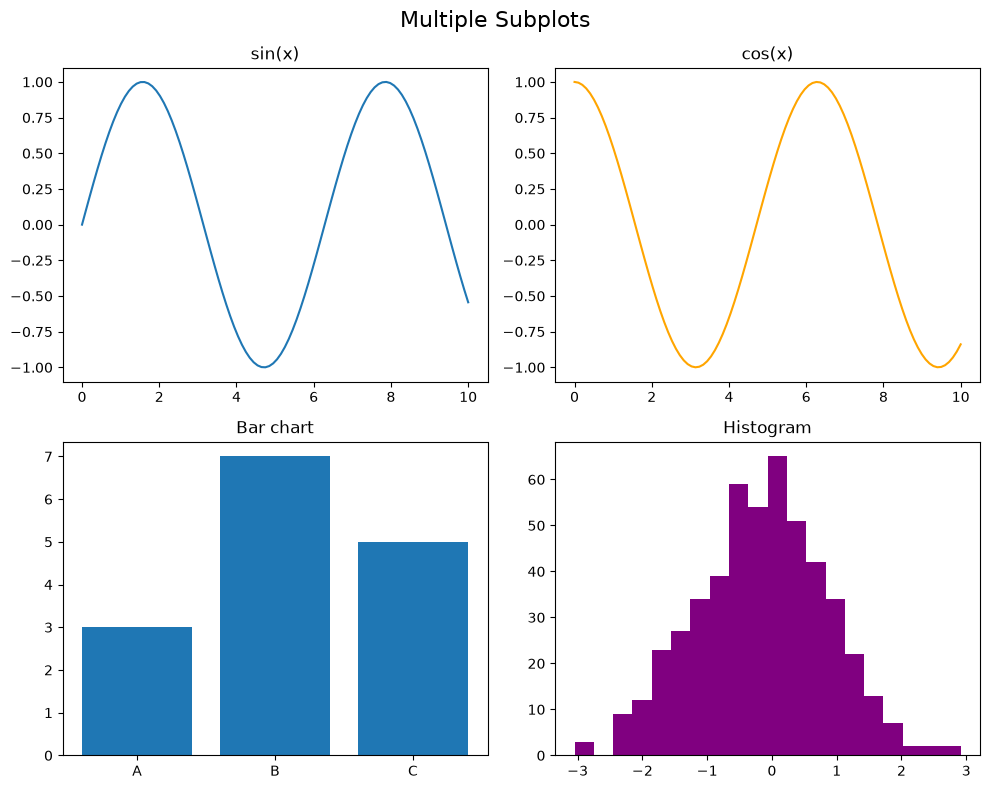

In [10]:
# =========================================================
# SUBPLOTS - the OBJECT-ORIENTED way (recommended for anything beyond a single quick plot)
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 8))   # 2x2 grid of Axes, figsize in inches

x = np.linspace(0, 10, 100)

axes[0, 0].plot(x, np.sin(x))
axes[0, 0].set_title("sin(x)")

axes[0, 1].plot(x, np.cos(x), color="orange")
axes[0, 1].set_title("cos(x)")

axes[1, 0].bar(["A", "B", "C"], [3, 7, 5])
axes[1, 0].set_title("Bar chart")

axes[1, 1].hist(rng.normal(0, 1, 500), bins=20, color="purple")
axes[1, 1].set_title("Histogram")

fig.suptitle("Multiple Subplots", fontsize=16)
plt.tight_layout()     # automatically fixes spacing/overlap between subplots
plt.show()

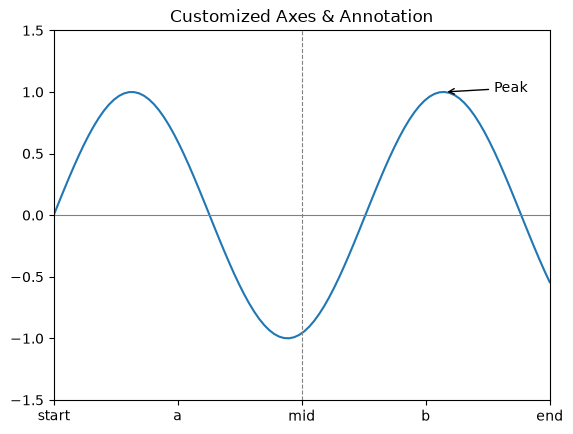

In [11]:
# =========================================================
# AXIS LIMITS, TICKS, ANNOTATIONS
# =========================================================

x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y)

ax.set_xlim(0, 10)               # set x-axis range explicitly
ax.set_ylim(-1.5, 1.5)
ax.set_xticks([0, 2.5, 5, 7.5, 10])          # custom tick positions
ax.set_xticklabels(["start", "a", "mid", "b", "end"])   # custom tick labels

# Annotate a specific point with an arrow and text
max_idx = np.argmax(y)
ax.annotate("Peak",
            xy=(x[max_idx], y[max_idx]),          # the point being annotated
            xytext=(x[max_idx] + 1, y[max_idx]),   # where the text goes
            arrowprops=dict(facecolor="black", arrowstyle="->"))

ax.axhline(0, color="gray", linewidth=0.8)   # horizontal reference line at y=0
ax.axvline(5, color="gray", linewidth=0.8, linestyle="--")   # vertical reference line

plt.title("Customized Axes & Annotation")
plt.show()

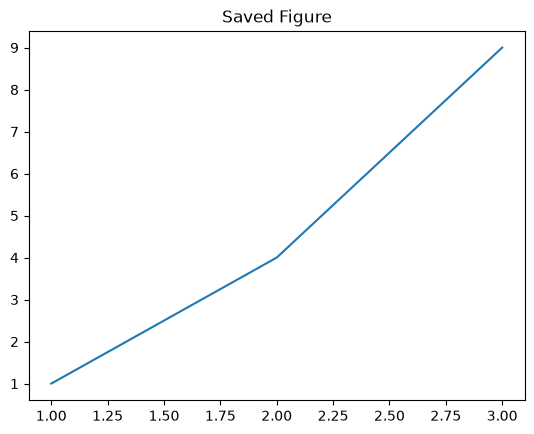

File saved: True


In [12]:
# =========================================================
# SAVING TO A FILE - useful for reports, READMEs, docs, etc.
# =========================================================

fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 4, 9])
ax.set_title("Saved Figure")

fig.savefig("my_plot.png", dpi=150, bbox_inches="tight")
# dpi -> resolution; bbox_inches="tight" -> trims excess whitespace around the figure
# Other formats work too: "my_plot.pdf", "my_plot.svg"

plt.show()

import os
print("File saved:", os.path.exists("my_plot.png"))
os.remove("my_plot.png")   # cleanup

<a id="7"></a>
# 7. The Object-Oriented API vs `pyplot`

There are two ways to use matplotlib:
- **`pyplot` (state-based)**: `plt.plot(...)`, `plt.title(...)` — implicitly acts on "the
  current figure/axes". Quick and fine for simple, one-off plots (used in most sections above).
- **Object-oriented**: `fig, ax = plt.subplots()` then `ax.plot(...)`, `ax.set_title(...)` —
  explicit and precise. **Preferred for anything with multiple subplots or reusable plotting
  functions**, since you're never relying on "whichever axes is currently active."

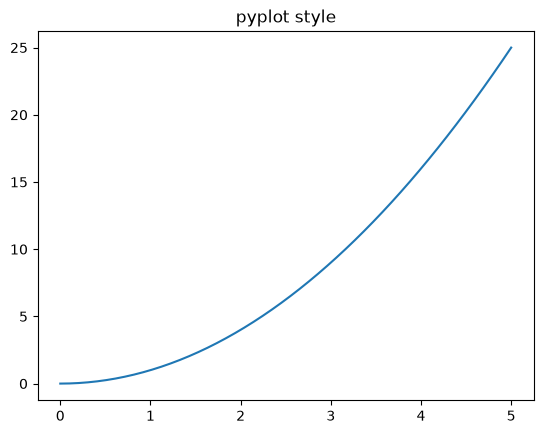

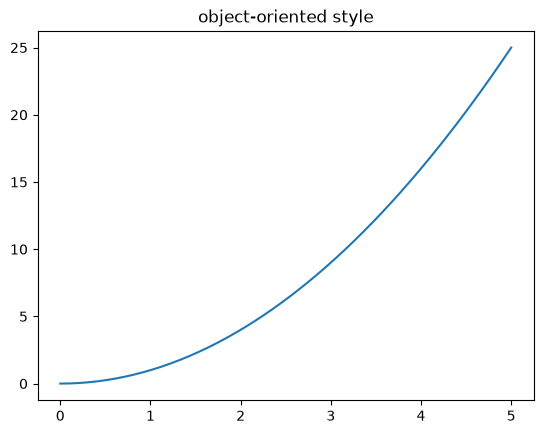

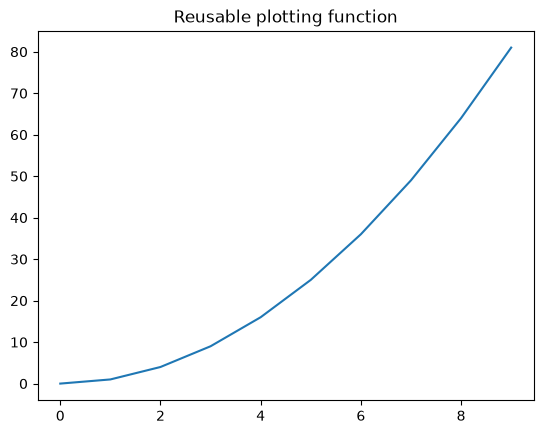

In [13]:
# =========================================================
# SIDE-BY-SIDE COMPARISON OF BOTH STYLES
# =========================================================

x = np.linspace(0, 5, 50)

# --- pyplot (state-based) style ---
plt.figure()
plt.plot(x, x**2)
plt.title("pyplot style")
plt.show()

# --- object-oriented style (recommended for real projects) ---
fig, ax = plt.subplots()
ax.plot(x, x**2)
ax.set_title("object-oriented style")
plt.show()

# A reusable plotting FUNCTION is much cleaner with the OO API, since it can accept
# an 'ax' to draw on rather than depending on a hidden global "current axes"
def plot_squares(ax, values):
    ax.plot(values, [v**2 for v in values])
    ax.set_title("Reusable plotting function")
    return ax

fig, ax = plt.subplots()
plot_squares(ax, range(10))
plt.show()

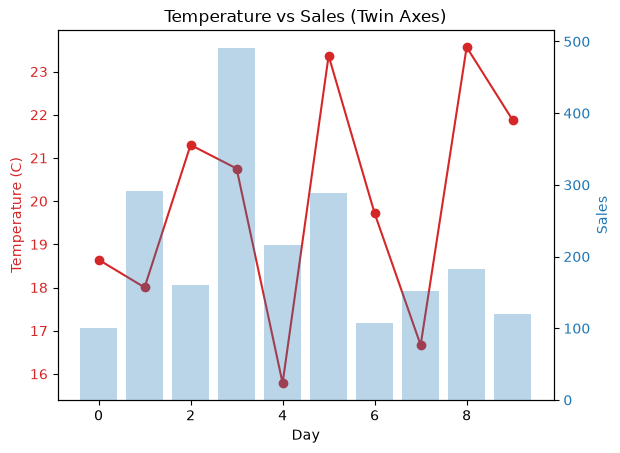

In [14]:
# =========================================================
# TWIN AXES - plotting two different scales on the same chart
# =========================================================

x = np.arange(10)
temperature = rng.normal(20, 3, 10)
sales = rng.integers(100, 500, 10)

fig, ax1 = plt.subplots()

ax1.plot(x, temperature, color="tab:red", marker="o")
ax1.set_xlabel("Day")
ax1.set_ylabel("Temperature (C)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()   # creates a second y-axis SHARING the same x-axis
ax2.bar(x, sales, alpha=0.3, color="tab:blue")
ax2.set_ylabel("Sales", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Temperature vs Sales (Twin Axes)")
plt.show()


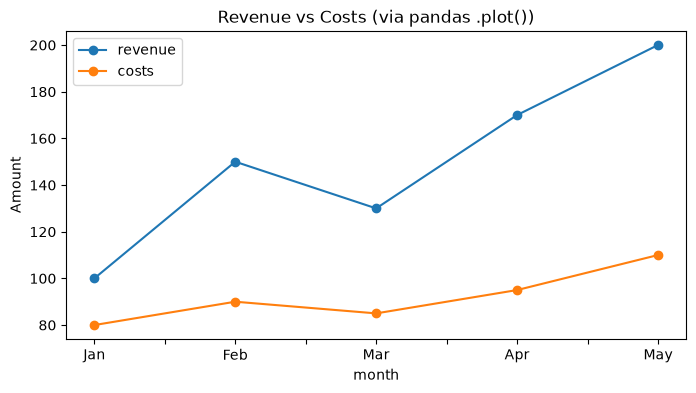

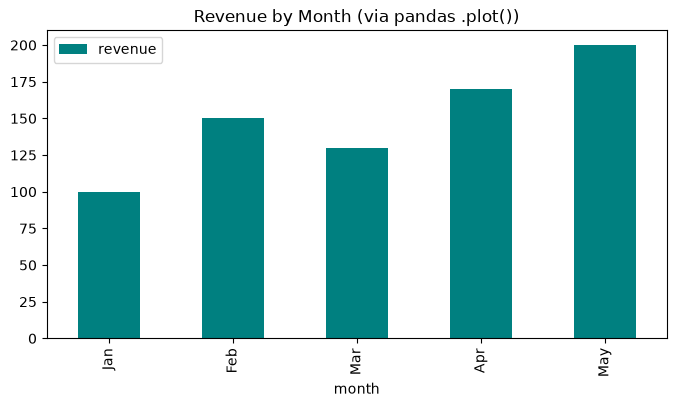

In [15]:
# =========================================================
# PLOTTING DIRECTLY FROM PANDAS - .plot() calls matplotlib under the hood
# =========================================================
import pandas as pd

df = pd.DataFrame({
    "month": ["Jan", "Feb", "Mar", "Apr", "May"],
    "revenue": [100, 150, 130, 170, 200],
    "costs": [80, 90, 85, 95, 110],
})

df.plot(x="month", y=["revenue", "costs"], kind="line", marker="o", figsize=(8, 4))
plt.title("Revenue vs Costs (via pandas .plot())")
plt.ylabel("Amount")
plt.show()

df.plot(x="month", y="revenue", kind="bar", color="teal", figsize=(8, 4))
plt.title("Revenue by Month (via pandas .plot())")
plt.show()
